In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, ConfusionMatrixDisplay, classification_report

np.random.seed(0)
plt.style.use('seaborn-v0_8-whitegrid')

In [25]:
RANDOM_STATE = 0
PATH = "dataset.csv"
POPULAR_THRESHOLD = 70

feat_cols = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms", "key", "mode", "time_signature", "explicit"]

In [26]:
df = pd.read_csv(PATH)

popularity_scores = df["popularity"]
is_popular = popularity_scores >= POPULAR_THRESHOLD
df["label_popular"] = is_popular

feat_table = df[feat_cols]

feat_medians = feat_table.median()
new_feat = feat_table.fillna(feat_medians)

X = new_feat.to_numpy()
y = df["label_popular"].to_numpy()

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_size = X_train_scaled.shape[0]
test_size = X_test_scaled.shape[0]
print("Train size: " + str(train_size))
print("Test size: " + str(test_size))

Train size: 91200
Test size: 22800


EFFECT OF n_estimators AND max_features
n_estimators=1: Test Acc = 0.9398
n_estimators=10: Test Acc = 0.9665
n_estimators=50: Test Acc = 0.9693
n_estimators=100: Test Acc = 0.9701
n_estimators=200: Test Acc = 0.9694
n_estimators=500: Test Acc = 0.9694

max_features=1: Test Acc = 0.9701
max_features=2: Test Acc = 0.9702
max_features=4: Test Acc = 0.9701
max_features=6: Test Acc = 0.9701
max_features=8: Test Acc = 0.97
max_features=10: Test Acc = 0.9701
max_features=14: Test Acc = 0.9701


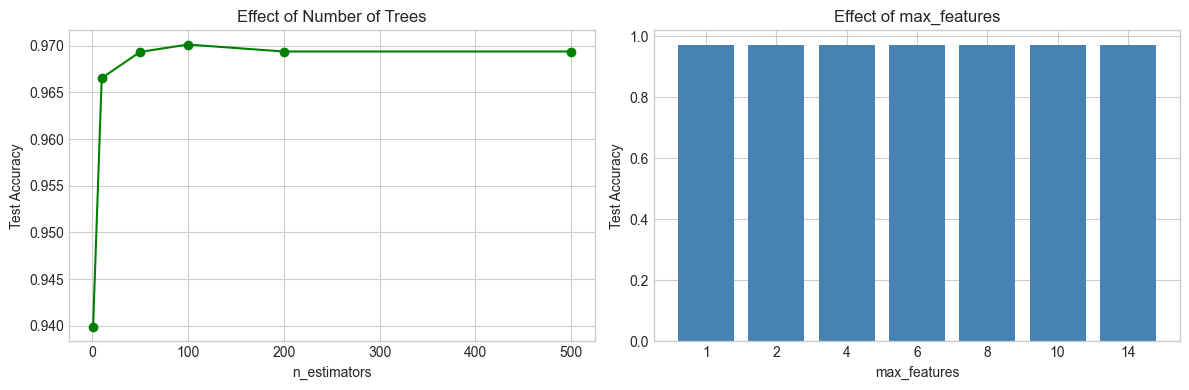

In [28]:
print("=" * 50)
print("EFFECT OF n_estimators AND max_features")
print("=" * 50)

n_trees_list = [1, 10, 50, 100, 200, 500]
rf_acc = []
for n in n_trees_list:
    model = RandomForestClassifier(n_estimators=n, max_features=3, random_state=RANDOM_STATE, class_weight="balanced")
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    rf_acc.append(acc)
    print("n_estimators=" + str(n) + ": Test Acc = " + str(round(acc, 4)))

print("")
m_list = [1, 2, 4, 6, 8, 10, 14]
mf_acc = []
for m in m_list:
    model = RandomForestClassifier(n_estimators=100, max_features=m, random_state=RANDOM_STATE, class_weight="balanced")
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    mf_acc.append(acc)
    print("max_features=" + str(m) + ": Test Acc = " + str(round(acc, 4)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(n_trees_list, rf_acc, 'g-o')
axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Effect of Number of Trees')

axes[1].bar([str(m) for m in m_list], mf_acc, color='steelblue')
axes[1].set_xlabel('max_features'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Effect of max_features')
plt.tight_layout(); plt.show()

In [29]:
rf_model = RandomForestClassifier(n_estimators=200, max_features=3, random_state=RANDOM_STATE, class_weight="balanced")
rf_model.fit(X_train_scaled, y_train)

threshold = 0.5
probability_matrix = rf_model.predict_proba(X_test_scaled)
test_popular_proba = probability_matrix[:, 1]
y_test_pred = test_popular_proba >= threshold

In [30]:
accuracy = accuracy_score(y_test, y_test_pred)
error = 1.0 - accuracy
precision = precision_score(y_test, y_test_pred, pos_label=True)
recall = recall_score(y_test, y_test_pred, pos_label=True)
f1_metric = f1_score(y_test, y_test_pred, pos_label=True)
roc_auc = roc_auc_score(y_test, test_popular_proba)
confusion = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix:")
print(confusion)
print("")
print("Threshold: " + str(threshold))
print("Accuracy: " + str(accuracy))
print("Error: " + str(error))
print("Precision: " + str(precision))
print("Recall: " + str(recall))
print("F1 score: " + str(f1_metric))
print("ROC-AUC: " + str(roc_auc))

print("")
print("Classification report:")
print(classification_report(y_test, y_test_pred, target_names=["not_popular", "popular"]))

roc_false_positive_rate, roc_true_positive_rate, roc_threshold_values = roc_curve(
    y_test, test_popular_proba
)

Confusion matrix:
[[21427   279]
 [  419   675]]

Threshold: 0.5
Accuracy: 0.9693859649122807
Error: 0.030614035087719316
Precision: 0.7075471698113207
Recall: 0.6170018281535649
F1 score: 0.6591796875
ROC-AUC: 0.905671432476989

Classification report:
              precision    recall  f1-score   support

 not_popular       0.98      0.99      0.98     21706
     popular       0.71      0.62      0.66      1094

    accuracy                           0.97     22800
   macro avg       0.84      0.80      0.82     22800
weighted avg       0.97      0.97      0.97     22800



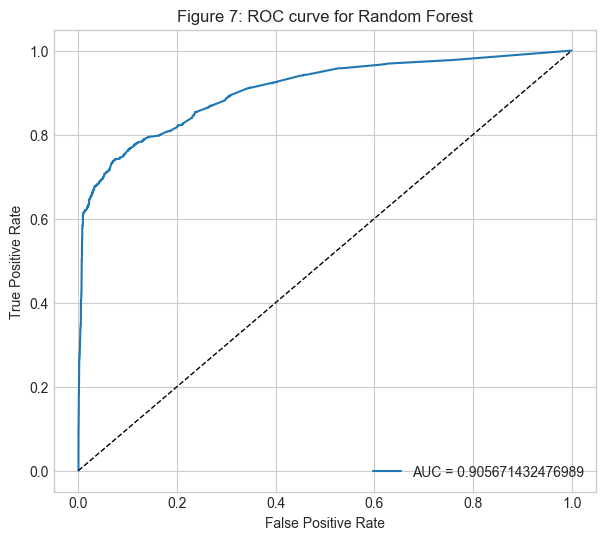

In [31]:
plt.figure(figsize=(7, 6))
auc_label = "AUC = " + str(roc_auc)
plt.plot(roc_false_positive_rate, roc_true_positive_rate, label=auc_label)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 7: ROC curve for Random Forest")
plt.legend(loc="lower right")
plt.show()

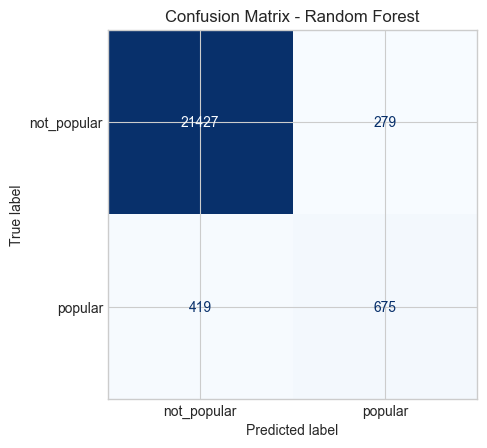

In [32]:
confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["not_popular", "popular"],
)
confusion_matrix_display.plot(values_format="d", cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.show()

Feature importances (sorted):
         feature  importance
          energy    0.102035
    acousticness    0.099955
        loudness    0.099821
instrumentalness    0.098527
     duration_ms    0.095327
        liveness    0.093484
         valence    0.087766
     speechiness    0.086080
    danceability    0.084107
           tempo    0.083765
             key    0.042528
        explicit    0.011379
            mode    0.009501
  time_signature    0.005726


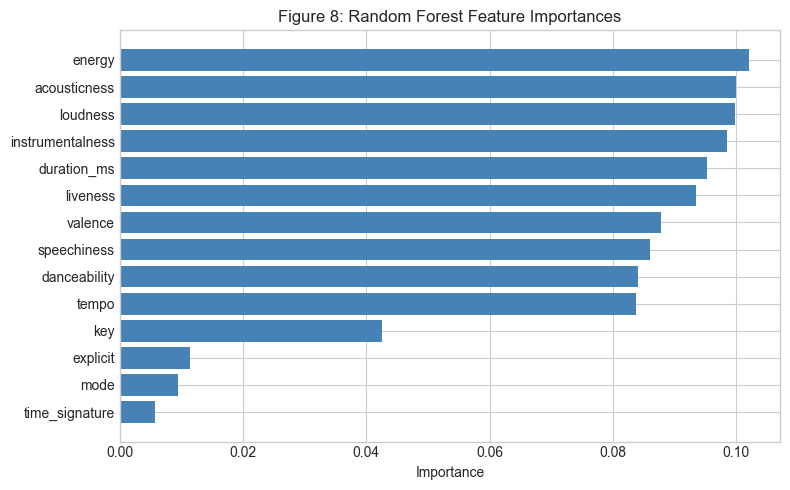

In [33]:
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({"feature": feat_cols, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=False)

print("Feature importances (sorted):")
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"], color="steelblue")
plt.xlabel("Importance")
plt.title("Figure 8: Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()